# NB02: ChromaDB GraphRAG (Section A)

## What
This notebook builds a full local GraphRAG pipeline using ChromaDB: chunking, embeddings, persistence, relationship extraction, graph construction, community detection, and local/global retrieval.

## Why
ChromaDB gives a low-ops local baseline that is easy to reproduce, inspect, and debug before moving to managed vector infrastructure.

## When
Use this notebook when you want rapid local iteration, deterministic artifact generation, and direct graph + retrieval introspection.

## Tradeoffs
- Local persistence is simple but does not provide managed horizontal scaling.
- Metadata-rich retrieval is convenient but full scans (`collection.get`) can become expensive at larger scales.
- Graph extraction here uses pragmatic heuristics, not a relation-classification model.

## Alternatives
- **Why ChromaDB**: local persistent DB with straightforward metadata handling and notebook ergonomics.
- **Why not FAISS**: excellent ANN core, but requires extra plumbing for durable metadata-centric workflows.
- **Why not Weaviate**: strong production platform, but introduces service and schema operations overhead for local tutorial workflows.
- **Why not Qdrant**: strong option with good filtering, but still adds daemon/runtime management compared with an embedded local baseline.

## Production Considerations
- Keep embedding model consistent between indexing and query time.
- Version graph artifacts with corpus slice metadata.
- Move relationship extraction from heuristics to supervised/LLM extraction for higher precision.
- Enforce retrieval latency/error monitoring before deployment.

In [1]:
# Input: project modules and plotting stack.
# Output: notebook runtime configured for deterministic GraphRAG execution.
# Logic: load dependencies, configure paths, and set plotting defaults.
# Complexity: O(1).
from __future__ import annotations

import json
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

sys.path.append(str(Path.cwd().parent))

from src.chroma_retriever import (
    create_or_replace_collection,
    create_chroma_client,
    entity_search,
    reciprocal_rank_fusion,
    vector_search,
)
from src.chunking import (
    build_chunk_lookup,
    build_chunks,
    chunk_statistics,
    load_chunks,
    persist_chunks,
)
from src.config import settings
from src.data_pipeline import load_medmentions_records, load_persisted_records, persist_records
from src.embeddings import EmbeddingBundle, embed_texts, load_embedding_bundle, persist_embedding_bundle
from src.graph_builder import (
    build_entity_graph,
    community_summaries,
    community_summary_text,
    concept_id_from_query,
    detect_communities,
    extract_relationship_edges,
    graph_statistics,
    local_graph_expansion,
    rank_communities_for_query,
    relation_edge_statistics,
    serialize_relation_edges,
)
from src.utils import save_json, save_plot, timed_block

plt.rcParams["figure.figsize"] = (10, 6)
print(f"Project root: {settings.project_root}")
print(f"Embedding model: {settings.embedding_model}")

Project root: /home/ahmad/AI/Medical-Research-GraphRAG
Embedding model: qwen3-embedding:4b


## Step 1: Load Records and Build/Rehydrate Chunks

This notebook supports two paths:
1. Rehydrate persisted artifacts from previous runs.
2. Build artifacts from real MedMentions records when needed.

In [2]:
# Input: persisted records/chunks if available, otherwise raw MedMentions records.
# Output: in-memory `records` and `chunks`.
# Logic: prefer reuse for reproducibility; fallback to deterministic rebuild.
# Complexity: O(N) for load or O(total_chars) for chunk build.
records_path = settings.processed_dir / "medmentions_records.json"
chunks_path = settings.processed_dir / "medmentions_chunks.parquet"

if records_path.exists():
    records = load_persisted_records(records_path)
else:
    with timed_block("Load and persist MedMentions records"):
        records = load_medmentions_records(max_records=settings.max_records)
        persist_records(records, records_path)

if chunks_path.exists():
    chunks = load_chunks(chunks_path)
else:
    with timed_block("Build and persist chunks"):
        chunks = build_chunks(records, chunk_size=settings.chunk_size, chunk_overlap=settings.chunk_overlap)
        persist_chunks(chunks, chunks_path)

print(f"Records loaded: {len(records):,}")
print(f"Chunks loaded: {len(chunks):,}")
pd.DataFrame([chunk_statistics(chunks)])

Records loaded: 4,392
Chunks loaded: 5,098


,total_chunks,avg_chunk_length,median_chunk_length,p95_chunk_length,avg_entity_count,pct_chunks_with_entities
0,5098,1391.577678,1515.5,1961.0,47.787368,99.980384


## Step 2: Embed Chunks with `qwen3-embedding:4b`

We embed chunk text once and persist vectors for reuse by both ChromaDB and Pinecone notebooks.

In [3]:
# Input: chunk texts and embedding model configuration.
# Output: normalized embedding matrix aligned to chunk IDs.
# Logic: use persisted bundle when available, otherwise compute and save.
# Complexity: O(number_of_chunks * embedding_latency).
bundle_matrix_path = settings.processed_dir / "chunk_embeddings.npy"
bundle_ids_path = settings.processed_dir / "chunk_embedding_ids.json"

if bundle_matrix_path.exists() and bundle_ids_path.exists():
    bundle = load_embedding_bundle(settings.processed_dir)
else:
    with timed_block("Embed chunks"):
        matrix = embed_texts([chunk.text for chunk in chunks], model=settings.embedding_model, batch_size=64)
    bundle = EmbeddingBundle(chunk_ids=[chunk.chunk_id for chunk in chunks], matrix=matrix)
    persist_embedding_bundle(bundle, settings.processed_dir)

print("Embedding matrix shape:", bundle.matrix.shape)

Embedding matrix shape: (5098, 2560)


## Step 3: Persist ChromaDB Collection

ChromaDB persistence stores vectors + metadata in `chroma_db/` for local retrieval workflows.

In [4]:
# Input: chunk records and embedding matrix.
# Output: populated Chroma collection.
# Logic: create fresh collection and batch-add vectors with metadata.
# Complexity: O(number_of_chunks).
client = create_chroma_client(str(settings.chroma_dir))
collection = create_or_replace_collection(client, "medmentions_chroma_section_a")

batch_size = 128
for start in range(0, len(chunks), batch_size):
    end = min(start + batch_size, len(chunks))
    batch_chunks = chunks[start:end]
    collection.add(
        ids=[chunk.chunk_id for chunk in batch_chunks],
        documents=[chunk.text for chunk in batch_chunks],
        embeddings=bundle.matrix[start:end].tolist(),
        metadatas=[
            {
                "pmid": chunk.pmid,
                "split": chunk.split,
                "chunk_index": int(chunk.chunk_index),
                "entity_count": int(chunk.entity_count),
                "concept_ids": "|".join(chunk.concept_ids),
                "entity_texts": "|".join(chunk.entity_texts),
                "title": chunk.title[:512],
            }
            for chunk in batch_chunks
        ],
    )

print("Chroma collection name:", collection.name)
print("Chroma chunk count:", collection.count())

2026-06-22 09:40:01 | INFO | create_or_replace_collection completed in 2.91s


Chroma collection name: medmentions_chroma_section_a
Chroma chunk count: 5098


## Step 4: Relationship Extraction and Graph Construction

### Relationship extraction (heuristic baseline)
We extract relation labels from chunk text patterns to enrich graph edges with explainable relationship metadata.

### Why this baseline
Heuristic extraction is transparent and fast for tutorials. In production, replace with trained relation extraction or LLM extraction with audit traces.

In [5]:
# Input: chunk metadata with concept IDs and chunk text.
# Output: typed relation edges + relation-aware entity graph.
# Logic: extract pairwise relation evidence and attach relation metadata on graph edges.
# Complexity: O(sum(entities_per_chunk^2)).
relation_edges = extract_relationship_edges(chunks)
relation_stats = relation_edge_statistics(relation_edges)

graph = build_entity_graph(
    chunks,
    min_entity_frequency=2,
    min_edge_weight=1,
    relation_edges=relation_edges,
)

graph_stats = graph_statistics(graph)
print("Graph stats:")
pd.DataFrame([graph_stats])

print("Relation stats:")
pd.DataFrame([relation_stats])

2026-06-22 09:50:31 | INFO | Extracted 4342106 relationship evidence edges


2026-06-22 09:50:54 | INFO | Graph built with 15454 nodes and 2191052 edges
2026-06-22 09:50:54 | INFO | build_entity_graph completed in 22.97s
Graph stats:
Relation stats:


,total_edges,relation_type_counts
0,4342106,"{'associated_with': 1123666, 'co_occurs_with':..."


## Step 5: Community Detection (Global GraphRAG Context)

We detect graph communities with Louvain to build higher-level thematic summaries used by global retrieval context.

In [6]:
# Input: relation-aware concept graph.
# Output: community partition + top-entity summaries.
# Logic: Louvain clustering then summary generation by degree centrality.
# Complexity: approximately near-linear for sparse graphs.
partition = detect_communities(graph, resolution=1.0)
summaries = community_summaries(graph, partition, top_entities=12)

community_df = pd.DataFrame(
    [
        {
            "community_id": row["community_id"],
            "size": row["size"],
            "num_edges": row["num_edges"],
            "top_entity": row["top_entities"][0]["label"] if row["top_entities"] else "",
        }
        for row in summaries
    ]
)
community_df.head(10)

2026-06-22 09:52:08 | INFO | Detected 6 communities
2026-06-22 09:52:08 | INFO | detect_communities completed in 73.51s


,community_id,size,num_edges,top_entity
0,0,4809,321857,patients
1,1,3984,249474,expression
2,5,3844,236468,qualitative
3,3,2739,162517,findings
4,4,69,744,inherited
5,2,9,36,AR


## Step 6: Graph Visualizations

We render graph and community visuals to inspect topology and cluster structure.

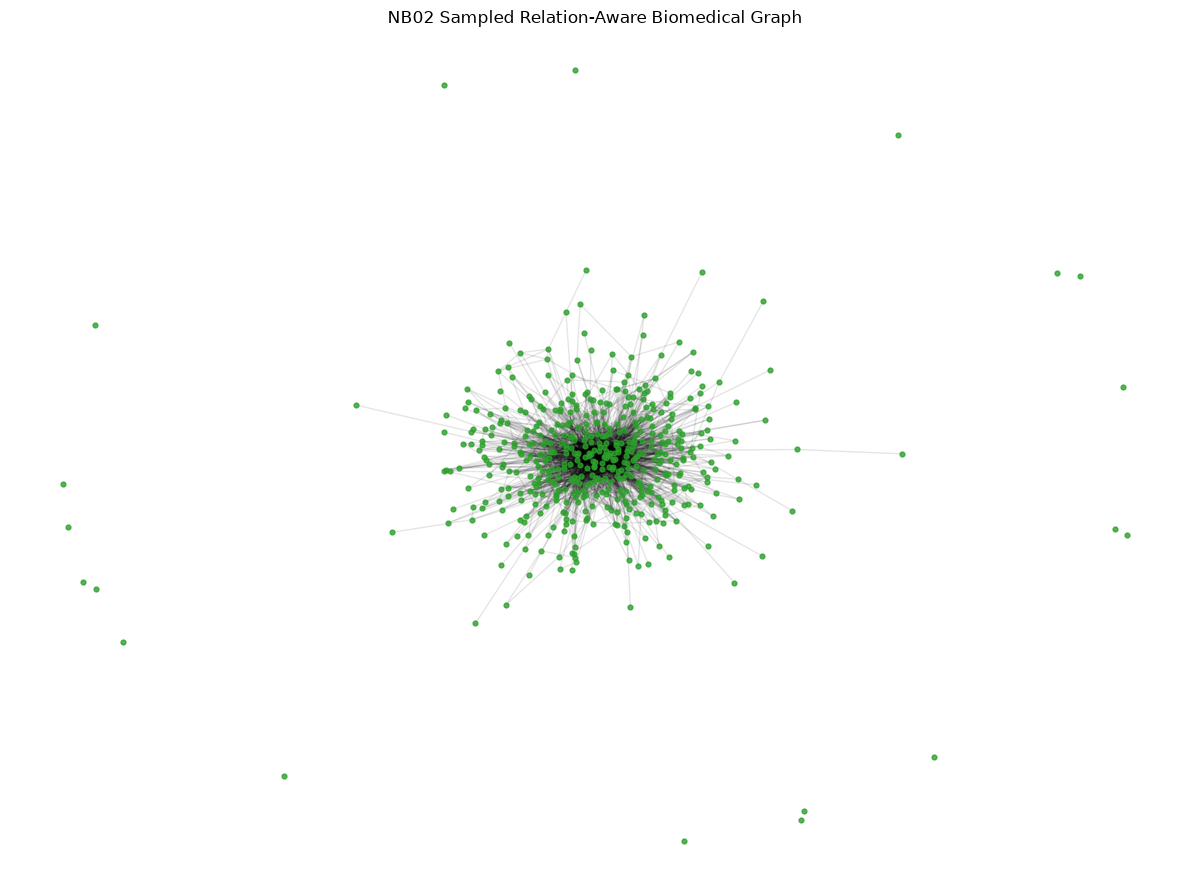

<Figure size 1000x600 with 0 Axes>

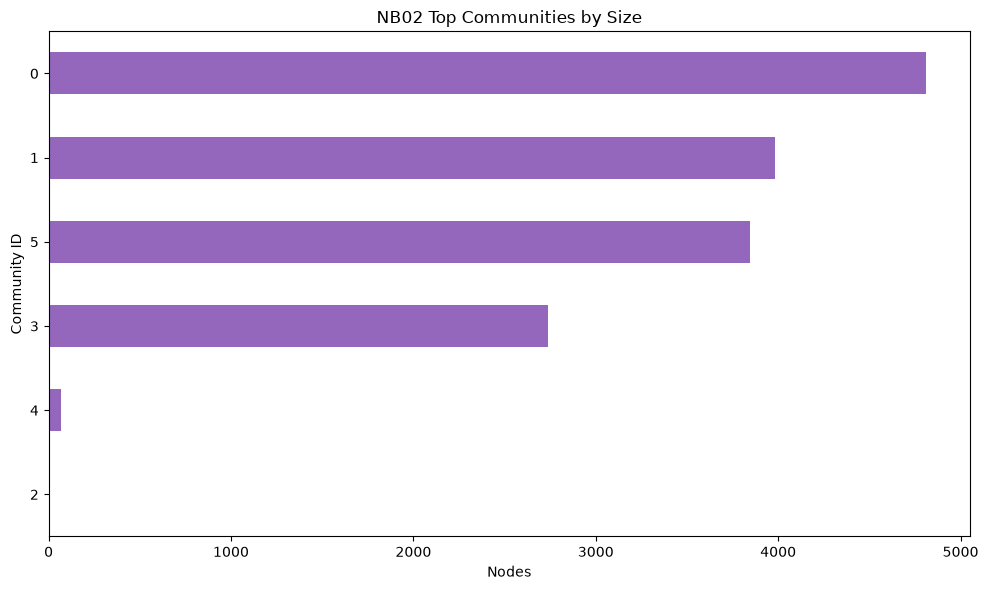

In [7]:
# Input: graph and community summary table.
# Output: graph and community visual artifacts.
# Logic: sampled node drawing + top-community bar chart.
# Complexity: O(sample_nodes + sample_edges).
rng = np.random.default_rng(settings.random_seed)
sample_nodes = list(graph.nodes())
if len(sample_nodes) > 500:
    sample_nodes = rng.choice(sample_nodes, size=500, replace=False).tolist()

sample_graph = graph.subgraph(sample_nodes)
plt.figure(figsize=(12, 9))
pos = nx.spring_layout(sample_graph, seed=settings.random_seed, k=0.35)
nx.draw_networkx_nodes(sample_graph, pos, node_size=12, alpha=0.8, node_color="#2ca02c")
nx.draw_networkx_edges(sample_graph, pos, alpha=0.10)
plt.title("NB02 Sampled Relation-Aware Biomedical Graph")
plt.axis("off")
save_plot(settings.figures_dir / "nb02_graph_sample.png")
plt.show()

plt.figure(figsize=(10, 6))
community_df.head(15).sort_values("size").plot(
    kind="barh",
    x="community_id",
    y="size",
    legend=False,
    color="#9467bd",
    title="NB02 Top Communities by Size",
)
plt.xlabel("Nodes")
plt.ylabel("Community ID")
save_plot(settings.figures_dir / "nb02_community_sizes.png")
plt.show()

## Step 7: Local Search and Global Search Demonstration

- **Local search**: expand k-hop neighborhood around query concepts.
- **Global search**: rank and summarize the most relevant communities.

In [8]:
# Input: sample biomedical query.
# Output: local neighborhood + global community contexts.
# Logic: concept matching, graph expansion, and summary ranking.
# Complexity: O(local_neighborhood + num_communities).
sample_query = "What does the literature report about diabetes and insulin resistance?"
query_concepts = concept_id_from_query(sample_query, chunks)

local_ctx = local_graph_expansion(graph, query_concepts, hops=settings.local_graph_hops)
global_ctx = rank_communities_for_query(query_concepts, partition, summaries, top_k=3)

print("Query:", sample_query)
print("Matched concept IDs:", query_concepts[:8])
print("Local nodes:", len(local_ctx.get("nodes", [])))
print("Local edges:", len(local_ctx.get("edges", [])))

for idx, community in enumerate(global_ctx, start=1):
    print(f"\n--- Global Community Context {idx} ---")
    print(community_summary_text(community)[:1000])

Query: What does the literature report about diabetes and insulin resistance?
Matched concept IDs: ['C0023866', 'C0028873', 'C0011847', 'C0684224', 'C4281815', 'C0021641', 'C0034693', 'C0034721']
Local nodes: 15454
Local edges: 2191052

--- Global Community Context 1 ---
Community 0 (size=4809, edges=321857):
Key biomedical concepts:
- patients (concept_id=C0030705, freq=1653, centrality=0.893)
- study (concept_id=C2603343, freq=1445, centrality=0.698)
- treatment (concept_id=C0087111, freq=838, centrality=0.612)
- evaluated (concept_id=C0220825, freq=634, centrality=0.579)
- associated with (concept_id=C0332281, freq=811, centrality=0.577)
- age (concept_id=C0001779, freq=548, centrality=0.567)
- analysis (concept_id=C0936012, freq=861, centrality=0.532)
- results (concept_id=C1274040, freq=737, centrality=0.521)
- years (concept_id=C0439234, freq=483, centrality=0.517)
- compared (concept_id=C1707455, freq=623, centrality=0.511)
- data (concept_id=C1511726, freq=740, centrality=0.510

## Step 8: GraphRAG Retrieval Example (Vector + Entity Fusion)

We fuse vector retrieval and entity-channel retrieval with reciprocal rank fusion (RRF).

In [9]:
# Input: sample query and Chroma collection.
# Output: ranked GraphRAG retrieval examples.
# Logic: run vector search and entity search, then fuse rankings with RRF.
# Complexity: O(vector_search + metadata_scan).
vector_results = vector_search(collection, sample_query, top_k=12)
entity_results = entity_search(collection, concept_ids=local_ctx.get("nodes", [])[:100], top_k=12)
fused_results = reciprocal_rank_fusion({"vector": vector_results, "entity": entity_results}, top_k=8)

print("Top fused retrieval results:")
for idx, row in enumerate(fused_results[:5], start=1):
    print(f"[{idx}] id={row['id']} score={row['score']:.4f} sources={row.get('sources', [])}")
    print(row["text"][:220], "...\n")

2026-06-22 09:52:21 | INFO | Embedded batch 1/1 (1 texts)
2026-06-22 09:52:21 | INFO | Embedded 1 texts with model qwen3-embedding:4b
2026-06-22 09:52:21 | INFO | embed_texts completed in 4.15s


Top fused retrieval results:
[1] id=27777170_c0000 score=0.0164 sources=['vector']
Rheumatoid arthritis, insulin resistance, and diabetes

Recent progress in the management of rheumatoid arthritis (RA) is turning attention toward comorbidities, such as diabetes. The objectives of this review are to cla ...

[2] id=27697751_c0000 score=0.0164 sources=['entity']
MiR-495 functions as an adjuvant to radiation therapy by reducing the radiation-induced bystander effect

The radiation-induced bystander effect (RIBE) is an important factor in tumor radiation therapy because it may inc ...

[3] id=28406758_c0001 score=0.0161 sources=['vector']
erence at baseline. Participants with triglycerides in the highest tertile (≥2.11 mmol/l) had a 4.0-times higher risk of developing incident diabetes compared to those in the lowest tertile (p=0.03). Notably, neither wai ...

[4] id=27754397_c0000 score=0.0161 sources=['entity']
Total Energy Expenditure in Obese Kuwaiti Primary School Children Assessed by

## Step 9: Persist Artifacts

This notebook persists artifacts required by later notebooks and by the README reporting flow.

### Historical outputs
Existing project outputs from prior runs remain available for comparison.

### Pending outputs
Any newly introduced metrics/figures in this notebook should be populated during the later execution phase.

In [10]:
# Input: graph, communities, relations, and retrieval samples.
# Output: persisted graph/relation artifacts and summary tables.
# Logic: serialize reusable artifacts for NB03/NB04/NB05 and README sections.
# Complexity: O(V + E + relation_edges).
with (settings.graph_dir / "entity_graph.pkl").open("wb") as f:
    pickle.dump(graph, f)

save_json(partition, settings.graph_dir / "community_partition.json")
save_json(summaries, settings.graph_dir / "community_summaries.json")
save_json(serialize_relation_edges(relation_edges), settings.graph_dir / "relation_edges.json")

community_df.to_csv(settings.tables_dir / "nb02_community_summary.csv", index=False)
pd.DataFrame([graph_stats]).to_csv(settings.tables_dir / "nb02_graph_stats.csv", index=False)
pd.DataFrame([relation_stats]).to_csv(settings.tables_dir / "nb02_relation_stats.csv", index=False)

# Save retrieval example table.
retrieval_rows = [
    {
        "rank": idx + 1,
        "chunk_id": row["id"],
        "score": float(row["score"]),
        "sources": "|".join(row.get("sources", [])),
        "text_preview": row["text"][:260],
    }
    for idx, row in enumerate(fused_results[:8])
]
pd.DataFrame(retrieval_rows).to_csv(settings.tables_dir / "nb02_retrieval_examples.csv", index=False)

print("Saved NB02 Chroma GraphRAG artifacts and tables.")

Saved NB02 Chroma GraphRAG artifacts and tables.
